# Student Placement Prediction Using Machine Learning

### Objective

The objective of this project is to develop a Machine Learning model that predicts whether a student will be placed based on their academic performance, skills, training, and extracurricular activities. The project involves data preprocessing, exploratory data analysis, model training, evaluation, and prediction using classification algorithms.

In [1]:
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder

# Splitting the dataset
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# Model Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
placement_data = pd.read_csv(r"C:\Users\jnpat\OneDrive\Desktop\internship project\placementdata.csv")
# Display the first five rows
    
placement_data.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [3]:
# Display the last five rows

placement_data.tail()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
9995,9996,7.5,1,1,2,72,3.9,Yes,No,85,66,NotPlaced
9996,9997,7.4,0,1,0,90,4.8,No,No,84,67,Placed
9997,9998,8.4,1,3,0,70,4.8,Yes,Yes,79,81,Placed
9998,9999,8.9,0,3,2,87,4.8,Yes,Yes,71,85,Placed
9999,10000,8.4,0,1,1,66,3.8,No,No,62,66,NotPlaced


In [4]:
# Checking the number of rows and columns

print("Dataset Shape:", placement_data.shape)

Dataset Shape: (10000, 12)


In [5]:
# Display dataset information

placement_data.info()

print("\nData Types")
print(placement_data.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB

Data Types
StudentID                      i

In [6]:
# Checking missing values

placement_data.isnull().sum()

StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [7]:
# Checking duplicate records

placement_data.duplicated().sum()

np.int64(0)

In [8]:
# Statistical summary

placement_data.describe().T

,count,mean,std,min,25%,50%,75%,max
StudentID,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
CGPA,10000.0,7.69801,0.640131,6.5,7.40,7.7,8.20,9.1
Internships,10000.0,1.04920,0.665901,0.0,1.00,1.0,1.00,2.0
Projects,10000.0,2.02660,0.867968,0.0,1.00,2.0,3.00,3.0
Workshops/Certifications,10000.0,1.01320,0.904272,0.0,0.00,1.0,2.00,3.0
AptitudeTestScore,10000.0,79.44990,8.159997,60.0,73.00,80.0,87.00,90.0
SoftSkillsRating,10000.0,4.32396,0.411622,3.0,4.00,4.4,4.70,4.8
SSC_Marks,10000.0,69.15940,10.430459,55.0,59.00,70.0,78.00,90.0
HSC_Marks,10000.0,74.50150,8.919527,57.0,67.00,73.0,83.00,88.0


In [9]:
# Display the count of each class in the target variable

placement_data["PlacementStatus"].value_counts()

PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64

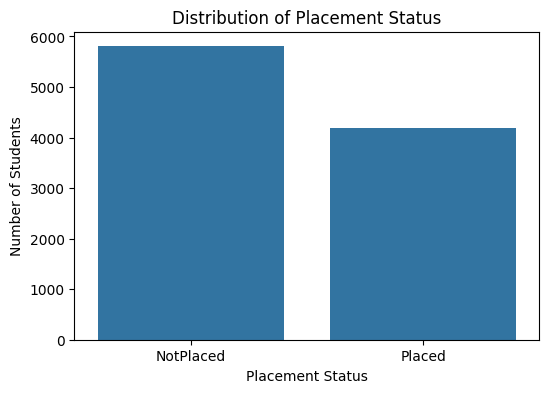

In [10]:
# Visualize the target variable(bar graph -- width 6,height 4 )

plt.figure(figsize=(6,4))

sns.countplot(x="PlacementStatus", data=placement_data)

plt.title("Distribution of Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.show()

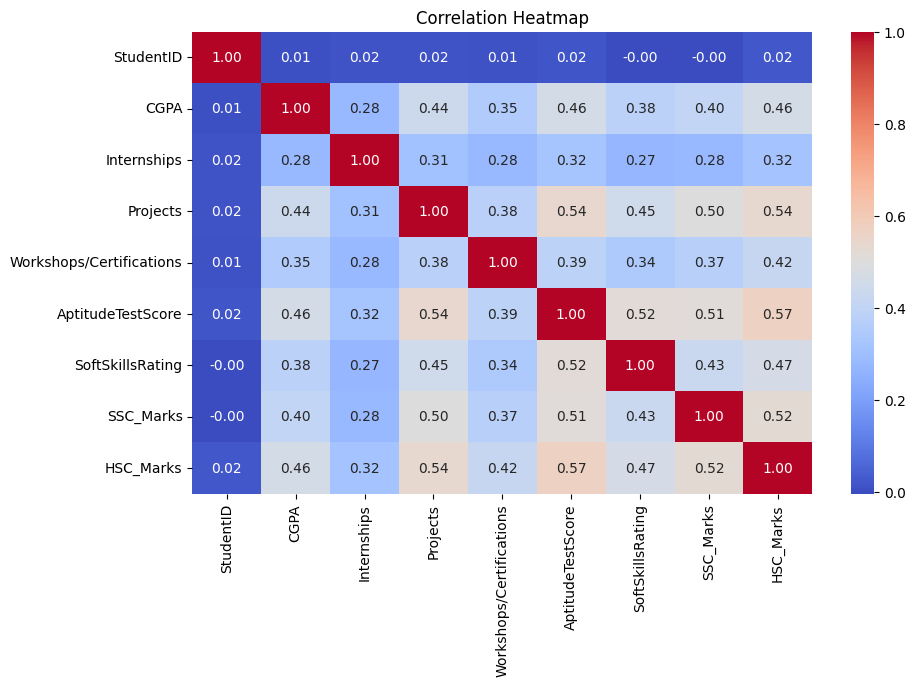

In [11]:
# Correlation heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    placement_data.corr(numeric_only=True),
    annot=True, # show colour and value in each box 
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [12]:
# Create LabelEncoder object

encoder = LabelEncoder()

# Encode categorical columns

placement_data["ExtracurricularActivities"] = encoder.fit_transform(
    placement_data["ExtracurricularActivities"]
)

placement_data["PlacementTraining"] = encoder.fit_transform(
    placement_data["PlacementTraining"]
)

placement_data["PlacementStatus"] = encoder.fit_transform(
    placement_data["PlacementStatus"]
)

# Display first five rows after encoding

placement_data.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,0,0,61,79,0
1,2,8.9,0,3,2,90,4.0,1,1,78,82,1
2,3,7.3,1,2,2,82,4.8,1,0,79,80,0
3,4,7.5,1,1,2,85,4.4,1,1,81,80,1
4,5,8.3,1,2,2,86,4.5,1,1,74,88,1


In [13]:
# Selecting features and target

X = placement_data.drop(columns=["StudentID", "PlacementStatus"])

y = placement_data["PlacementStatus"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (10000, 10)
Target Shape : (10000,)


In [14]:
# Splitting the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (8000, 10)
Testing Features  : (2000, 10)
Training Target   : (8000,)
Testing Target    : (2000,)


In [15]:
# Create and train the Logistic Regression model

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train) 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
# Predict using Logistic Regression

y_pred_lr = logistic_model.predict(X_test)

# Calculate accuracy

# formula = (Correct Predictions/Total Prediction​)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8085


In [17]:
# Create and train Decision Tree model

decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

# Prediction

y_pred_dt = decision_tree.predict(X_test)

# Accuracy

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.721


In [18]:
# Create and train Random Forest model

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

# Prediction

y_pred_rf = random_forest.predict(X_test)

# Accuracy

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7915


In [19]:
# Compare model accuracy

accuracy = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        round(lr_accuracy, 4),
        round(dt_accuracy, 4),
        round(rf_accuracy, 4)
    ]
})

accuracy.reset_index(drop=True, inplace=True)

accuracy

,Model,Accuracy
0,Logistic Regression,0.8085
1,Decision Tree,0.7210
2,Random Forest,0.7915


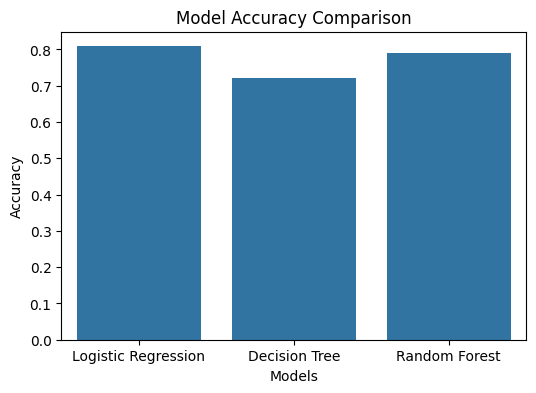

In [20]:
# Accuracy comparison graph

plt.figure(figsize=(6,4))

sns.barplot(data=accuracy, x="Model", y="Accuracy")

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

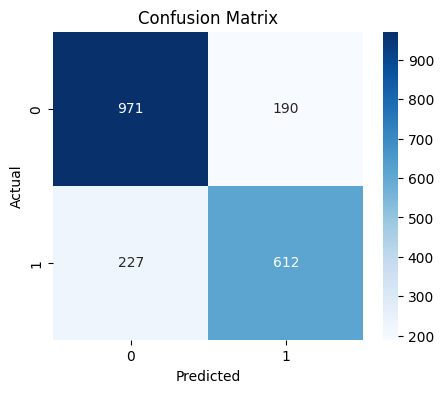

In [21]:
# Confusion Matrix for Random Forest

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
# Classification Report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.81      0.84      0.82      1161
           1       0.76      0.73      0.75       839

    accuracy                           0.79      2000
   macro avg       0.79      0.78      0.78      2000
weighted avg       0.79      0.79      0.79      2000



In [23]:
# Sample student data
new_student = pd.DataFrame({
    "CGPA": [8.2],
    "Internships": [2],
    "Projects": [4],
    "Workshops/Certifications": [3],
    "AptitudeTestScore": [85],
    "SoftSkillsRating": [4.5],
    "ExtracurricularActivities": [1],
    "PlacementTraining": [1],
    "SSC_Marks": [88],
    "HSC_Marks": [84]
})

print("New Student Data")
display(new_student)

prediction = random_forest.predict(new_student)

print("\nPrediction Result")

if prediction[0] == 1:
    print("Placement Status : Placed")
else:
    print("Placement Status : Not Placed")

New Student Data


,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
0,8.2,2,4,3,85,4.5,1,1,88,84



Prediction Result
Placement Status : Placed
